




Teacher: Jacques Bourg    
Helper:  Gaëlle Letort

Spot detection for RNA imaging

<img src="T.png" alt="FISH imaging" width="1206" height="219">

II Signal : what is it ? 

- Orders of magnitude

- PSF

- Noise



In [1]:
import numpy as np
import matplotlib.pyplot as plt

Intro to convolution

<p align="center">
  <img src="./2D_Convolution_Animation.gif" alt="2D Convolution Animation" title="2D Convolution Animation">
</p>

Michael Plotke. (2013). 2D Convolution Animation. Wikimedia Commons. Retrieved 2025

In [3]:
import matplotlib.colors as mcolors

def custom_color_map(pow=1, nb_points= 256, max = 1):
        """
        number of points
        pow: between 0 and 1.
        
        fig, ax = plt.subplots(figsize=figsize)
        q = ax.imshow(im_2d_mip_n,  vmin = 0, vmax=1, cmap=custom_cmap)
        cbar = fig.colorbar(q, ax=ax)
        """

        linear_ramp_d = np.flip(np.linspace(0, max, nb_points))
        linear_ramp_u = np.linspace(0, max, nb_points)
        powered_ramp_d = linear_ramp_d ** pow
        powered_ramp_u = linear_ramp_u ** pow

        colors = np.zeros((nb_points, 4))
        colors[:, 0] = 1  
        colors[:, 1] = powered_ramp_d  
        colors[:, 2] = powered_ramp_d  
        colors[:, 3] = 1.0 
        
        colors2 = np.zeros((nb_points, 4))
        colors2[:, 0] = powered_ramp_u  
        colors2[:, 1] = powered_ramp_u  
        colors2[:, 2] = 1  
        colors2[:, 3] = 1.0 
        
        
        colors_cat  = np.vstack((colors2, colors))
        
        # Alpha channel (fully opaque)
        custom_cmap = mcolors.ListedColormap(colors_cat)
        return custom_cmap

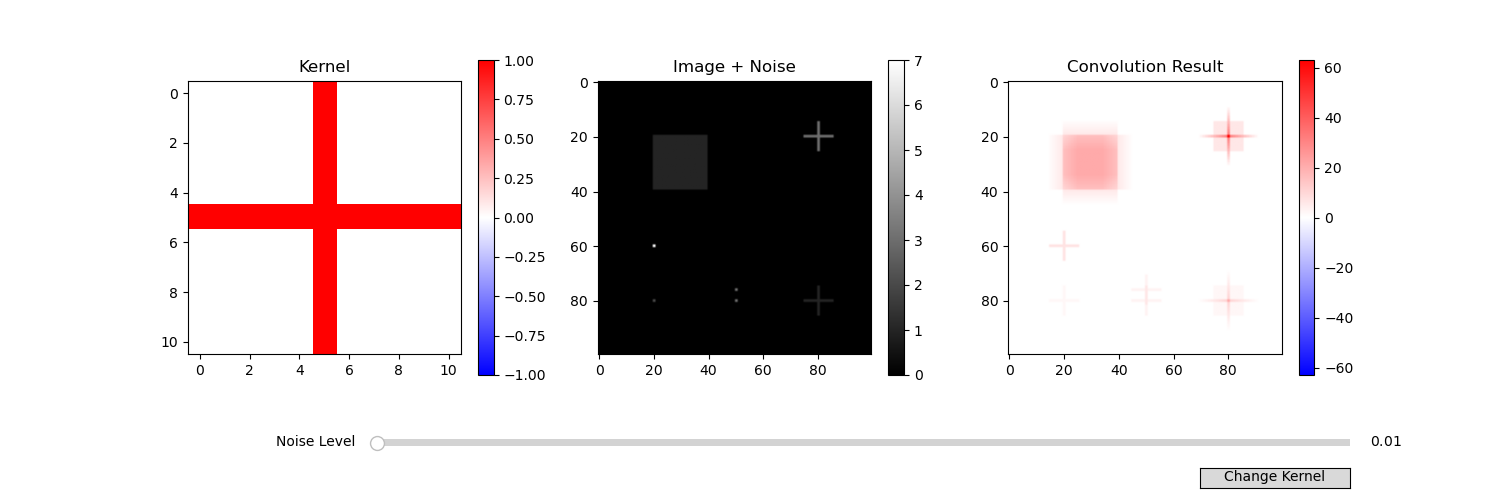

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from skimage import data, util, filters, color
from scipy.ndimage import correlate

%matplotlib widget

def add_gaussian_noise(image, var=0.01):
    noisy_image = image + var*np.random.rand(np.shape(image)[0], np.shape(image)[1])       #util.random_noise(image, mode='gaussian', var=var)
    return noisy_image   #(noisy_image * 255).astype(np.uint8)

def apply_convolution(image, kernel):
    return correlate(image, kernel)

l = 5

kernel = np.zeros((11,11))
kernel[5-l:5+l+1,5] = 1
kernel[5,5-l:5+l+1] = 1

kernel2 = np.zeros((11,11))
kernel2[5,5] = 1

kernel3 = np.zeros((11,11))
kernel3[4:7,4:7] = 1

kernel4 = np.zeros((11,11))
kernel4[:,5] = 1

kernel5 = np.zeros((13,13))
kernel5[5:8, 5:8] = -1/8
kernel5[6,6] = 1

kernel6 = np.zeros((11,11))
kernel6[3:8,3:8] = -9/12
kernel6[4:7,4:7] = 1


kernel7 = np.zeros((13,13))
lp = 6
kernel7[6-lp:6+lp+1,5] = -21/48
kernel7[6-lp:6+lp+1,6] = -21/48
kernel7[6-lp:6+lp+1,7] = -21/48
kernel7[5,6-lp:6+lp+1] = -21/48
kernel7[6,6-lp:6+lp+1] = -21/48
kernel7[7,6-lp:6+lp+1] = -21/48 
kernel7[6-l:6+l+1,6] = 1
kernel7[6,6-l:6+l+1] = 1
 
kernel8 = np.zeros((11,11))
kernel8[:,3:8] = 1
kernel8[:,4:7] = -22/33

kernel9 = np.zeros((15,15))
lpp = 7
kernel9[7-lpp:7+lpp+1,5] = -69/56
kernel9[7-lpp:7+lpp+1,6] = -69/56
kernel9[7-lpp:7+lpp+1,7] = -69/56
kernel9[7-lpp:7+lpp+1,8] = -69/56
kernel9[7-lpp:7+lpp+1,9] = -69/56

kernel9[5,7-lpp:7+lpp+1] = -69/56
kernel9[6,7-lpp:7+lpp+1] = -69/56
kernel9[7,7-lpp:7+lpp+1] = -69/56
kernel9[8,7-lpp:7+lpp+1] = -69/56  
kernel9[9,7-lpp:7+lpp+1] = -69/56
 
lp = 6
kernel9[7-lp:7+lp+1,6] = 1
kernel9[7-lp:7+lp+1,7] = 1
kernel9[7-lp:7+lp+1,8] = 1
kernel9[6,7-lp:7+lp+1] = 1
kernel9[7,7-lp:7+lp+1] = 1
kernel9[8,7-lp:7+lp+1] = 1 


kernel10 = np.zeros((15,15))

lpp = 7
kernel10[7-lpp:7+lpp+1,5] = -21/104
kernel10[7-lpp:7+lpp+1,6] = -21/104
kernel10[7-lpp:7+lpp+1,7] = -21/104
kernel10[7-lpp:7+lpp+1,8] = -21/104
kernel10[7-lpp:7+lpp+1,9] = -21/104

kernel10[5,7-lpp:7+lpp+1] = -21/104
kernel10[6,7-lpp:7+lpp+1] = -21/104
kernel10[7,7-lpp:7+lpp+1] = -21/104
kernel10[8,7-lpp:7+lpp+1] = -21/104  
kernel10[9,7-lpp:7+lpp+1] = -21/104
 
lp = 5
kernel10[7-lp:7+lp+1,7] = 1
kernel10[7,7-lp:7+lp+1] = 1



kernel_list = [kernel, kernel2, kernel3, kernel4, kernel5, kernel6, kernel7, kernel8, kernel9, kernel10]

image = np.zeros((100,100))
image[20:40,20:40] = 1
image[20:40,20:40] = 1
image[60,20]       = 7
image[80,20]       = 2

l = 5
image[80-l:80+l+1,80] = 1
image[80,80-l:80+l+1] = 1

image[20-l:20+l+1,80] = 3
image[20,80-l:80+l+1] = 3

image[80, 50] = 3
image[80-4, 50] = 3


ind = 0
actual_kernel = kernel_list[ind]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(bottom=0.25)

ax_img1, ax_img2, ax_img3 = axes

a = np.max(np.abs(actual_kernel))
cm_k = custom_color_map(pow=1, nb_points= 256, max = a)
img1 = ax_img1.imshow(actual_kernel, cmap=cm_k, vmin=-a, vmax= a)
fig.colorbar(img1, ax=ax_img1)

img2 = ax_img2.imshow(image, cmap='gray')
fig.colorbar(img2, ax=ax_img2)

conv_im = apply_convolution(image, actual_kernel)
b = np.max(np.abs(conv_im))
cm_l = custom_color_map(pow=1, nb_points= 256, max = 1)

img3 = ax_img3.imshow(conv_im, vmin = -b, vmax = b, cmap=cm_l)
fig.colorbar(img3, ax=ax_img3)

ax_img1.set_title('Kernel')
ax_img2.set_title('Image + Noise')
ax_img3.set_title('Convolution Result')

ax_slider = plt.axes([0.25, 0.1, 0.65, 0.03])
slider = Slider(ax_slider, 'Noise Level', 0.0, 5, valinit=0.01)

def update(val):
    noise_level = slider.val
    noisy_image = add_gaussian_noise(image, var=noise_level)
    img2.set_data(noisy_image)
    
    conv_im = apply_convolution(noisy_image, actual_kernel)
    b = np.max(np.abs(conv_im))    
    img3.set_data(conv_im)
    img3.set_clim([-b, b])
    fig.canvas.draw_idle()

slider.on_changed(update)

ax_button = plt.axes([0.8, 0.025, 0.1, 0.04])
button = Button(ax_button, 'Change Kernel')

def charge(event):
    global ind
    ind = ind + 1
    ind_vec = ind % len(kernel_list)
    actual_kernel = kernel_list[ind_vec]

    a = np.max(np.abs(actual_kernel))    
    img1.set_data(actual_kernel)  
    img1.set_clim([-a, a])

    noise_level = slider.val
    noisy_image = add_gaussian_noise(image, var=noise_level)
    img2.set_data(noisy_image)
    
    
    conv_im = apply_convolution(noisy_image, actual_kernel)
    b = np.max(np.abs(conv_im))    

    img3.set_data(conv_im)
    img3.set_clim([-b, b])

    fig.canvas.draw_idle()
    
button.on_clicked(charge)

plt.show()

In [7]:
# markdown

# influence of the kernel size
# apparition of artifacts
# impact of the noise level on a posterior thresholding
# selectivity of kernel when the kernel has a positive and negarive part (sum = 0)
# superposition effects
# effect of the inhibition
# effect of the width of the inhibition
# noise enhancement effect
# false positive at high noise (if there was a threshold)

5